# Entropy pooling

[Black–Litterman](05_Black_Litterman.md) blends views into the *mean* through a Gaussian
update. **Entropy pooling** is more general in two ways. First, it expresses views as
constraints on *any* moment — mean, variance, CVaR, skewness, kurtosis, even individual
covariances and correlations. Second, it does not assume normality: it reweights the empirical
scenarios so that the new distribution satisfies your views while staying as close as possible
(in relative entropy / Kullback–Leibler divergence) to the original. The output is a fully
reweighted prior, not just a shifted mean.

This is the second page of the view-prior arc — [Black–Litterman](05_Black_Litterman.md) came
first, and [Opinion Pooling](08_Opinion_Pooling.md) follows, combining several entropy-pooling
views into one.

In `PortfolioOptimisers`, `EntropyPoolingPrior` accepts a separate
`LinearConstraintEstimator` per quantity. Mind the naming: `mu_views` is the mean,
`sigma_views` is the **variance**, `var_views` is the **Value at Risk** and `cvar_views` the
**Conditional VaR** (tail-risk views), `sk_views`/`kt_views` are skewness/kurtosis, and
`cov_views`/`rho_views` target covariances/correlations. Each is a list of string constraints
over the `AssetSets` names.

> **When to reach for this**
>
> Reach for entropy pooling when your views are richer than "the mean will be x": views on
> volatility, tail risk (CVaR), skewness, or the correlation between two assets, possibly
> several at once. It is also the right tool when you distrust the normality assumption baked
> into Black–Litterman, since it reweights the empirical scenarios directly. For a simple
> mean-only view, Black–Litterman is lighter; to *combine* several entropy-pooling opinions,
> see Opinion Pooling.

In [1]:
using PortfolioOptimisers, PrettyTables

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=4)) %" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Naming assets and groups

As with Black–Litterman, views reference assets and groups by name through an
`AssetSets`.

In [3]:
sets = AssetSets(;
                 dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"],
                             "energy" => ["CVX"]))

AssetSets
   key ┼ String: "nx"
  ukey ┼ String: "ux"
  dict ┴ Dict{String, Vector{String}}: Dict("nx" => ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"], "tech" => ["AAPL", "AMD", "MSFT"], "energy" => ["CVX"])


## 3. Views on several moments

Entropy-pooling views are also plain strings, but they can target different quantities. Here we
state a **mean** view (Apple returns 8 bps) via `mu_views`, a **relative mean** view (tech
outperforms energy), and a **variance** view (pin Apple's variance) via `sigma_views`. The
comparison operators a view accepts depend on the moment: `mu_views`, `sigma_views`,
`sk_views`, `kt_views`, `cov_views` and `rho_views` take `==`, `>=` and `<=`; `var_views` (VaR)
takes only `==` and `>=`; and `cvar_views` (CVaR) takes only `==`. An unsupported operator
raises a `ParseError` listing the ones allowed for that view.

In [4]:
mu_views = LinearConstraintEstimator(; val = ["AAPL == 0.0008", "tech >= energy"])
sigma_views = LinearConstraintEstimator(; val = ["AAPL == 0.0003"])

ep = EntropyPoolingPrior(; sets = sets, mu_views = mu_views, sigma_views = sigma_views)

EntropyPoolingPrior
           pe ┼ EmpiricalPrior
              │        ce ┼ PortfolioOptimisersCovariance
              │           │   ce ┼ Covariance
              │           │      │    me ┼ SimpleExpectedReturns
              │           │      │       │   w ┴ nothing
              │           │      │    ce ┼ GeneralCovariance
              │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
              │           │      │       │    w ┴ nothing
              │           │      │   alg ┴ FullMoment()
              │           │   mp ┼ MatrixProcessing
              │           │      │     pdm ┼ Posdef
              │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
              │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
              │           │      │      dn ┼ nothing
              │           │      │      dt ┼ nothing
              │           │      │     alg ┼ nothing
            

## 4. Prior vs reweighted posterior

We compute the entropy-pooling posterior and compare both the mean **and** the variance of
Apple against the plain empirical prior — the mean view lifts the expected return while the
variance view tightens the dispersion, exactly as instructed.

In [5]:
pr_ep = prior(ep, rd)
pr_emp = prior(EmpiricalPrior(), rd)

i_aapl = findfirst(==("AAPL"), rd.nx)
pretty_table(DataFrame(["moment" => ["mean (AAPL)", "variance (AAPL)"],
                        "Empirical" => [pr_emp.mu[i_aapl], pr_emp.sigma[i_aapl, i_aapl]],
                        "Entropy pooling" =>
                            [pr_ep.mu[i_aapl], pr_ep.sigma[i_aapl, i_aapl]]]);
             formatters = [mmtfmt],
             title = "Apple moments: empirical vs entropy-pooling view")

Apple moments: empirical vs entropy-pooling view
┌─────────────────┬───────────┬─────────────────┐
│          moment │ Empirical │ Entropy pooling │
│          String │   Float64 │         Float64 │
├─────────────────┼───────────┼─────────────────┤
│     mean (AAPL) │ -0.1126 % │          0.08 % │
│ variance (AAPL) │    0.05 % │        0.0301 % │
└─────────────────┴───────────┴─────────────────┘


The full expected-returns vectors, side by side.

In [6]:
pretty_table(DataFrame(["Assets" => rd.nx, "Empirical" => pr_emp.mu,
                        "Entropy pooling" => pr_ep.mu]); formatters = [mmtfmt],
             title = "Expected returns: empirical vs entropy-pooling posterior")

Expected returns: empirical vs entropy-pooling posterior
┌────────┬───────────┬─────────────────┐
│ Assets │ Empirical │ Entropy pooling │
│ String │   Float64 │         Float64 │
├────────┼───────────┼─────────────────┤
│   AAPL │ -0.1126 % │          0.08 % │
│    AMD │ -0.2809 % │        0.0698 % │
│    BAC │ -0.0934 % │       -0.0124 % │
│    BBY │ -0.0279 % │        0.1921 % │
│    CVX │  0.1945 % │         0.243 % │
│     GE │ -0.0339 % │        0.1278 % │
│     HD │ -0.0707 % │        0.0504 % │
│    JNJ │  0.0307 % │        0.0766 % │
│    JPM │ -0.0417 % │        0.0256 % │
│     KO │  0.0497 % │         0.098 % │
│    LLY │  0.1305 % │        0.1942 % │
│    MRK │  0.1669 % │        0.1861 % │
│   MSFT │ -0.1206 % │        0.0932 % │
│    PEP │   0.039 % │        0.1159 % │
│      ⋮ │         ⋮ │               ⋮ │
└────────┴───────────┴─────────────────┘
                          6 rows omitted


Entropy-pooling posterior expected returns.

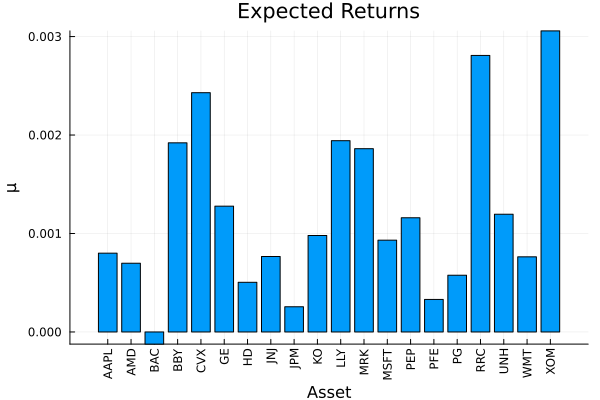

In [7]:
using StatsPlots, GraphRecipes
plot_mu(pr_ep, rd.nx)

## 5. Why it matters: views change the portfolio

Feeding the reweighted prior to a return-seeking optimiser tilts the portfolio toward the
view-favoured assets, just as Black–Litterman did — but here the *whole distribution*, not only
the mean, has been updated.

In [8]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

res_emp = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr_emp, slv = slv)))
res_ep = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                           opt = JuMPOptimiser(; pe = pr_ep, slv = slv)))

pretty_table(DataFrame(["Assets" => rd.nx, "Empirical" => res_emp.w,
                        "Entropy pooling" => res_ep.w]); formatters = [resfmt],
             title = "Maximum-ratio weights: empirical vs entropy pooling")

Maximum-ratio weights: empirical vs entropy pooling
┌────────┬───────────┬─────────────────┐
│ Assets │ Empirical │ Entropy pooling │
│ String │   Float64 │         Float64 │
├────────┼───────────┼─────────────────┤
│   AAPL │     0.0 % │           0.0 % │
│    AMD │     0.0 % │           0.0 % │
│    BAC │     0.0 % │           0.0 % │
│    BBY │     0.0 % │          6.52 % │
│    CVX │     0.0 % │           0.0 % │
│     GE │     0.0 % │           0.0 % │
│     HD │     0.0 % │           0.0 % │
│    JNJ │     0.0 % │           0.0 % │
│    JPM │     0.0 % │           0.0 % │
│     KO │     0.0 % │           0.0 % │
│    LLY │   0.002 % │         6.913 % │
│    MRK │  65.977 % │        44.433 % │
│   MSFT │     0.0 % │           0.0 % │
│    PEP │     0.0 % │        12.545 % │
│      ⋮ │         ⋮ │               ⋮ │
└────────┴───────────┴─────────────────┘
                          6 rows omitted


The composition plot makes the tilt visible.

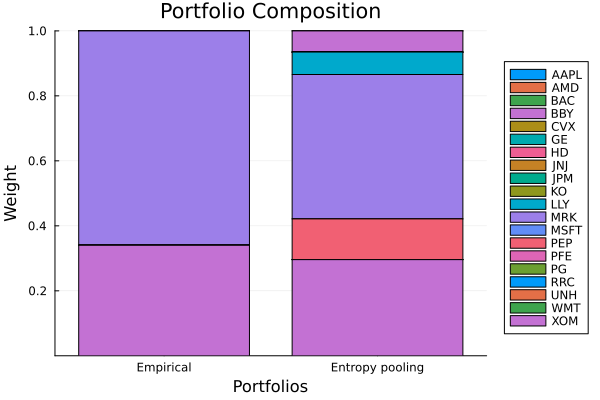

In [9]:
plot_stacked_bar_composition([res_emp, res_ep], rd;
                             xticks = (1:2, ["Empirical", "Entropy pooling"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*